# Setting

In [ ]:
import sys
import time
import contextlib
with open('install.log', 'a') as inpt:
    with contextlib.redirect_stdout(inpt):

        # -- Start installation --
        start = time.time()
        ! pip install gdown biopython memory_profiler
        import pandas as pd
        end = time.time()
        # -- End installation --
print(f'+ Time elapsed: ' + time.strftime('%Mm %Ss', time.gmtime(end - start)))

+ Time elapsed: 00m 02s


In [1]:
# Clone repo tapi hanya ambil struktur (tanpa file dulu)
!git clone --depth 1 --filter=blob:none --sparse https://github.com/setiawantirta/SCALR-Tax.git

# Masuk ke repo
%cd SCALR-Tax

# Aktifkan sparse checkout hanya untuk folder 'benchmark'
!git sparse-checkout set benchmark

# Lihat hasilnya
!ls benchmark

Kloning ke 'SCALR-Tax'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 2 (delta 0), pack-reused 0 (from 0)
Menerima objek: 100% (6/6), selesai.
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 2 (delta 0), pack-reused 0 (from 0)
Menerima objek: 100% (6/6), selesai.
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Menerima objek: 100% (4/4), 1.85 mebibita | 11.56 mebibita/detik, selesai.
remote: Total 4 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Menerima objek: 100% (4/4), 1

In [2]:
def reload_and_import_benchmark(import_mode="all"):
    """
    Fungsi untuk reload dan import dari package benchmark
    
    Parameters:
    import_mode (str): "all" untuk import *, "specific" untuk import fungsi tertentu
    """
    import importlib
    import sys
    import os
    import sys
    sys.path.append("/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax")

    print(f"🔄 Starting reload and import process (mode: {import_mode})...")
    
    # 🔧 FIX 1: Set environment variable untuk disable GPU sebelum import
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable all GPUs
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # Suppress TensorFlow warnings
    
    # 🔧 FIX 2: Daftar modul dengan urutan yang benar (parent dulu)
    benchmark_modules = [
        'benchmark',                    # Parent package HARUS pertama
        'benchmark.create_folder',      
        'benchmark.loader', 
        'benchmark.extract_split', 
        'benchmark.feature_reduction', 
        'benchmark.training'
    ]
    
    # Reload semua modul dengan error handling yang lebih baik
    for module_name in benchmark_modules:
        if module_name in sys.modules:
            try:
                importlib.reload(sys.modules[module_name])
                print(f"   ♻️ Reloaded: {module_name}")
            except Exception as e:
                print(f"   ⚠️ Failed to reload {module_name}: {e}")
        else:
            # 🔧 FIX 3: Import module jika belum ada di sys.modules
            try:
                __import__(module_name)
                print(f"   ✨ Imported (new): {module_name}")
            except Exception as e:
                print(f"   ⚠️ Failed to import {module_name}: {e}")
    
    # Import berdasarkan mode dengan error handling
    try:
        # 🔧 FIX 4: Pastikan parent package di-import terlebih dahulu
        import benchmark
        
        if import_mode == "all":
            # Import ALL functions explicitly
            import benchmark.create_folder as cf_module
            import benchmark.loader as loader_module
            import benchmark.extract_split as es_module
            import benchmark.feature_reduction as fr_module
            import benchmark.training as training_module
            
            # Get all public functions from each module
            for module_name, module in [
                ('create_folder', cf_module),
                ('loader', loader_module), 
                ('extract_split', es_module),
                ('feature_reduction', fr_module),
                ('training', training_module)
            ]:
                for attr_name in dir(module):
                    if not attr_name.startswith('_') and callable(getattr(module, attr_name)):
                        globals()[attr_name] = getattr(module, attr_name)
            
            print("✅ ALL functions imported explicitly")
            
        elif import_mode == "specific":
            # Import specific functions
            from benchmark.create_folder import create_project_folders
            from benchmark.loader import load_, run_extract_, load_all_csv_data
            from benchmark.extract_split import main_vectorization_process
            from benchmark.feature_reduction import benchmark_
            from benchmark.training import validate_naive_bayes_simple
            
            # Update globals
            globals().update({
                'create_project_folders': create_project_folders,
                'load_': load_,
                'run_extract_': run_extract_,
                'load_all_csv_data': load_all_csv_data,
                'main_vectorization_process': main_vectorization_process,
                'benchmark_': benchmark_,
                'validate_naive_bayes_simple': validate_naive_bayes_simple,
            })
            print("✅ Specific functions imported")
        
        # Print summary
        print(f"\n📋 Import completed with mode: {import_mode}")
        print(f"🖥️  GPU disabled - running in CPU-only mode")
        
    except Exception as e:
        print(f"❌ Import failed: {e}")
        import traceback
        traceback.print_exc()

# Penggunaan:
import os
os.environ['ENABLE_GPU_BENCHMARK'] = '1'  # Enable GPU
reload_and_import_benchmark("all")

🔄 Starting reload and import process (mode: all)...
   ✨ Imported (new): benchmark
   ♻️ Reloaded: benchmark.create_folder
   ♻️ Reloaded: benchmark.loader
   ♻️ Reloaded: benchmark.extract_split
   ♻️ Reloaded: benchmark.feature_reduction
   ♻️ Reloaded: benchmark.training
✅ ALL functions imported explicitly

📋 Import completed with mode: all
🖥️  GPU disabled - running in CPU-only mode
   ✨ Imported (new): benchmark
   ♻️ Reloaded: benchmark.create_folder
   ♻️ Reloaded: benchmark.loader
   ♻️ Reloaded: benchmark.extract_split
   ♻️ Reloaded: benchmark.feature_reduction
   ♻️ Reloaded: benchmark.training
✅ ALL functions imported explicitly

📋 Import completed with mode: all
🖥️  GPU disabled - running in CPU-only mode


In [3]:
# Test import
print("Testing function availability...")
try:
    print(f"✅ run_extract_ is available: {callable(run_extract_)}")
    print(f"✅ load_ is available: {callable(load_)}")
    print(f"✅ create_project_folders is available: {callable(create_project_folders)}")
except NameError as e:
    print(f"❌ Function not found: {e}")

Testing function availability...
✅ run_extract_ is available: True
✅ load_ is available: True
✅ create_project_folders is available: True


In [4]:
import os
folders = create_project_folders(project_name='rki_2025',
                       path=os.getcwd(),
                       DIR_path=None
                       )

🔹 Folder project_name berhasil dibuat: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025
🔹 Folder dataset berhasil dibuat: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset
🔹 Folder prep berhasil dibuat: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/prep
🔹 Folder model berhasil dibuat: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/model
🔹 Folder pred berhasil dibuat: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/pred


# Cek Data

In [5]:
from Bio import SeqIO

# Path file FASTA
fasta_path = "/home/tirta/Dokumen/0_dna-sequences-silva-v3-v4.fasta"

# Membaca isi file FASTA
with open(fasta_path, "r") as handle:
    records = list(SeqIO.parse(handle, "fasta"))

# Tampilkan jumlah sekuens dan contoh awal
print(f"Total sekuens ditemukan: {len(records)}\n")
print("=== Contoh 5 sekuens pertama ===\n")

for i, record in enumerate(records[:5]):
    print(f">{record.id}")
    print(str(record.seq)[:100] + "...")  # tampilkan 100 huruf pertama saja
    print()


Total sekuens ditemukan: 398508

=== Contoh 5 sekuens pertama ===

>CP013078.2406498.2408039
TGGGGAATTTTGGACAATGGGGGCAACCCTGATCCAGCCATCCCGCGTGTGCGATGAAGGCCTTCGGGTTGTAAAGCACTTTTGGCAGGAAAGAAACGGC...

>CP015924.1224168.1225721
TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGTGT...

>CP003278.287486.289015
TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGTGT...

>LS483321.16842.18378
TAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAACGCCGCGTGAGTGAAGAAGGTTTTCGGATCGTAAAGCTCTGTTGTTAGAGAAGAATGATG...

>CP012870.431955.433510
TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGGAG...



In [6]:
df_tax = load_(
    fasta='/home/tirta/Dokumen/0_dna-sequences-silva-v3-v4.fasta',
    tax='/home/tirta/Dokumen/0_taxonomy.tsv',
    only_bacteria=True,
    clean_ambiguous=False, 
)

Loading FASTA sequences...
Loaded 398508 sequences from FASTA
Loading taxonomy data...
Loaded 398508 sequences from FASTA
Loading taxonomy data...
Loaded taxonomy data: 436680 rows
Loaded taxonomy data: 436680 rows
After mapping sequences: 398508 rows
Extracting taxonomic levels...
Sample taxonomy string: d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Alcaligenaceae; g__Bordetella; s__Bordetella_pertussis
After mapping sequences: 398508 rows
Extracting taxonomic levels...
Sample taxonomy string: d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Alcaligenaceae; g__Bordetella; s__Bordetella_pertussis
Unique kingdoms found: ['d__Bacteria' 'd__Eukaryota' 'd__Archaea']
Filtered to bacteria only: 368859 sequences (removed 29649)
Final dataset: 368859 sequences with taxonomy
Unique kingdoms found: ['d__Bacteria' 'd__Eukaryota' 'd__Archaea']
Filtered to bacteria only: 368859 sequences (removed 29649)
Final dataset: 368859 sequences w

## Ekstract Level


🔬 K-MER FEATURE EXTRACTION PIPELINE
   • K-mer size: 8
   • Taxonomic levels: ['species']
   • Input sequences: 368,859
   • Expected features: 65,536 k-mers

⚡ BATCH MODE ENABLED
   • K >= 7 detected
   • Batch size: 500
   • Max memory: 8.0 GB
   • Save intermediate: True

🔬 PROCESSING LEVEL: SPECIES

🧹 FILTERING AMBIGUOUS BASES
   🔄 Replacing ambiguous bases...

🧹 FILTERING AMBIGUOUS BASES
   🔄 Replacing ambiguous bases...
   ✅ Cleaned 368,859 sequences

📊 STEP 1: LOAD DATA - SPECIES
   ✅ Cleaned 368,859 sequences

📊 STEP 1: LOAD DATA - SPECIES

📋 INITIAL DATA SUMMARY:
   • Total samples: 368,859
   • Total classes: 23389

📈 CLASS SIZE DISTRIBUTION (BEFORE FILTERING):

📋 INITIAL DATA SUMMARY:
   • Total samples: 368,859
   • Total classes: 23389

📈 CLASS SIZE DISTRIBUTION (BEFORE FILTERING):
   • Classes with 1 sample: 13209
   • Classes with 2-3 samples: 5156
   • Classes with 4-9 samples: 2984
   • Classes with ≥10 samples: 2040

⚠️  FILTERING: Dropping classes with < 100 samples

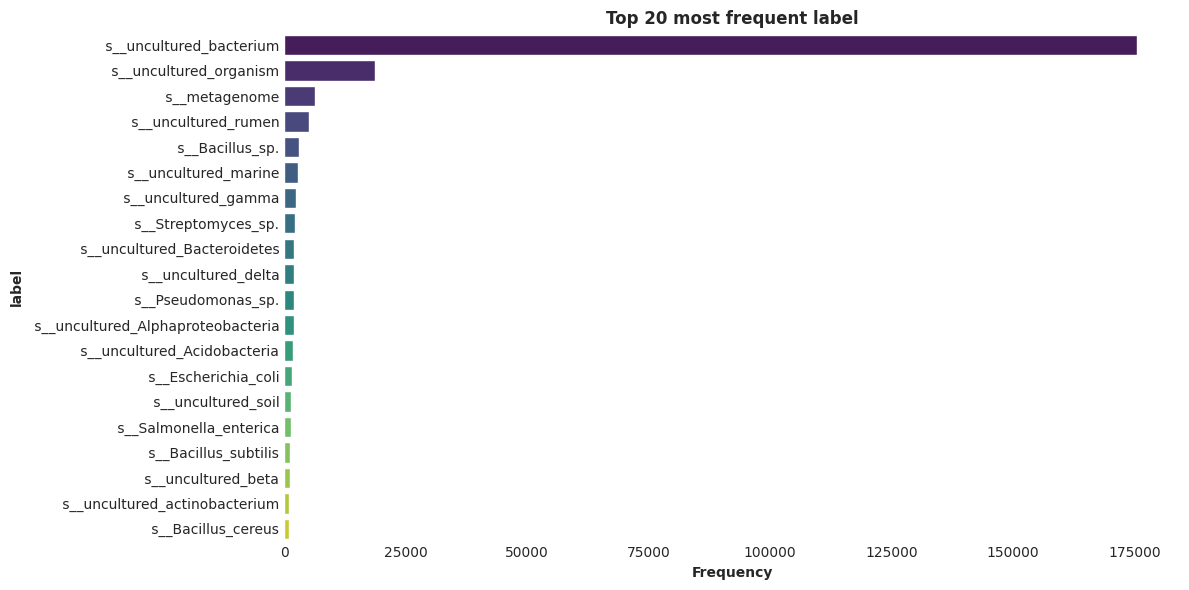

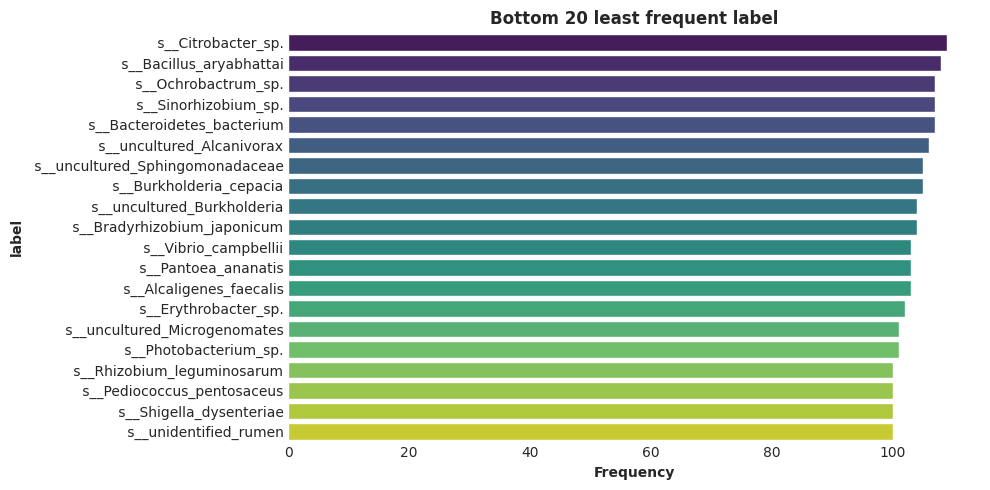

📊 Frequency plots saved to: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset/species


🧹 FILTERING UNWANTED LABELS
   Keywords to filter: ['uncultured', 'uncultivated', 'metagenome', 'metagenomic', 'unidentified', 'unknown', 'unclassified', 'environmental', 'clone']
   Case sensitive: False

📊 BEFORE FILTERING:
   • Total samples: 280,706
   • Total classes: 205

✅ AFTER FILTERING:
   • Remaining samples: 42,341
   • Remaining classes: 138

📉 FILTERED OUT:
   • Samples removed: 238,365 (84.92%)
   • Classes removed: 67 (32.68%)

   📋 Breakdown by keyword:
      • 'uncultured': 230,527 samples
      • 'metagenome': 6,902 samples
      • 'unidentified': 936 samples

🌳 APPLYING HIERARCHICAL GROUPING

🌳 HIERARCHICAL RARE CLASS GROUPING
   Threshold: 100 samples
   Strategy: group
   ✅ No rare classes found (all classes ≥ 100 samples)

📊 APPLYING CENTROID-BASED UNDERSAMPLING
   Strategy: centroid_closest

📊 CENTROID CLOSEST SAMPLING
   Sample fraction: 0.99
  

In [ ]:
# ✅ BEST PRACTICE: Preserve ALL rare taxa
kmer_size= 8
level = 'species'
csv_paths, paths_file = run_extract_(
    df_tax,
    columns_select=[f'{level}'],
    output_path='/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset',
    
    kmer_size=kmer_size,# ⚡ Batch mode auto-enabled

    # Batch parameters
    enable_batch_processing=True,
    batch_size=500,
    batch_kmer_threshold=7,
    max_memory_gb=8.0,
    save_intermediate=True,

    # ✅ NEW: Clean ambiguous bases
    filter_ambiguous_bases=True,
    ambiguous_handling='replace',      # Most conservative, "remove", "replace", "random"
    max_ambiguous_ratio=0.01,         # Allow max 1% ambiguous

    # ✅ NEW: Filtering configuration (DEFAULT)
    filter_uncultured=True,      # Remove 'uncultured' labels
    filter_metagenome=True,       # Remove 'metagenome' labels
    filter_unidentified=True,     # Remove 'unknown', 'unidentified'
    filter_environmental=True,   # Keep 'environmental' labels

    # 🆕 Keep all classes initially
    min_sample_freq=100,           # ✅ NO initial filtering
    
    # Balancing strategy
    imbalance_strategy='hierarchical_grouping',
    hierarchical_grouping=True,   # Group rare by genus

    # Balancing Using Under Sampling
    sampling_strategy='centroid_closest', # None untuk ambil semua data "centroid_closest","centroid_kmeans", "stratified","balanced"
    sample_fraction= 0.99,# 0.01, # jumlah baris yang diambil/disampel
    small_class_threshold= 100, # 20,     # Group if <10 samples, ✅ Group rare classes
    small_class_strategy='group',
    min_samples_per_class=10, # ✅ Ensure minimum per class
    
    # 🆕 Keep only top 100 classes (AFTER balancing)
    top_n_classes=100,  # ← NEW! Integer 100, 50, 200, etc.

    # Visualization
    create_plots=True,
    plot_top_n=False
)


🔬 PROCESSING LEVEL: SPECIES

🧹 FILTERING AMBIGUOUS BASES
   🔄 Replacing ambiguous bases with most likely alternatives...
   ✅ Cleaned 368,859 sequences

📊 STEP 1: LOAD DATA - SPECIES

📋 INITIAL DATA SUMMARY:
   • Total samples: 368,859
   • Total classes: 23389

📈 CLASS SIZE DISTRIBUTION (BEFORE FILTERING):
   • Classes with 1 sample: 13209
   • Classes with 2-3 samples: 5156
   • Classes with 4-9 samples: 2984
   • Classes with ≥10 samples: 2040

⚠️  FILTERING: Dropping classes with < 122 samples
   • Classes to drop: 23232
   • Samples to drop: 93,439

   📋 Examples of dropped classes:
       1.  s__uncultured_Rhizobiales: 121 samples
       2.  s__Psychrobacter_sp.: 121 samples
       3.  s__Sphingobacterium_sp.: 121 samples
       4.  s__Alteromonas_sp.: 120 samples
       5.  s__Candidatus_Phytoplasma: 119 samples
       6.  s__uncultured_eubacterium: 119 samples
       7.  s__uncultured_spirochete: 119 samples
       8.  s__Streptococcus_salivarius: 117 samples
       9.  s__Lys

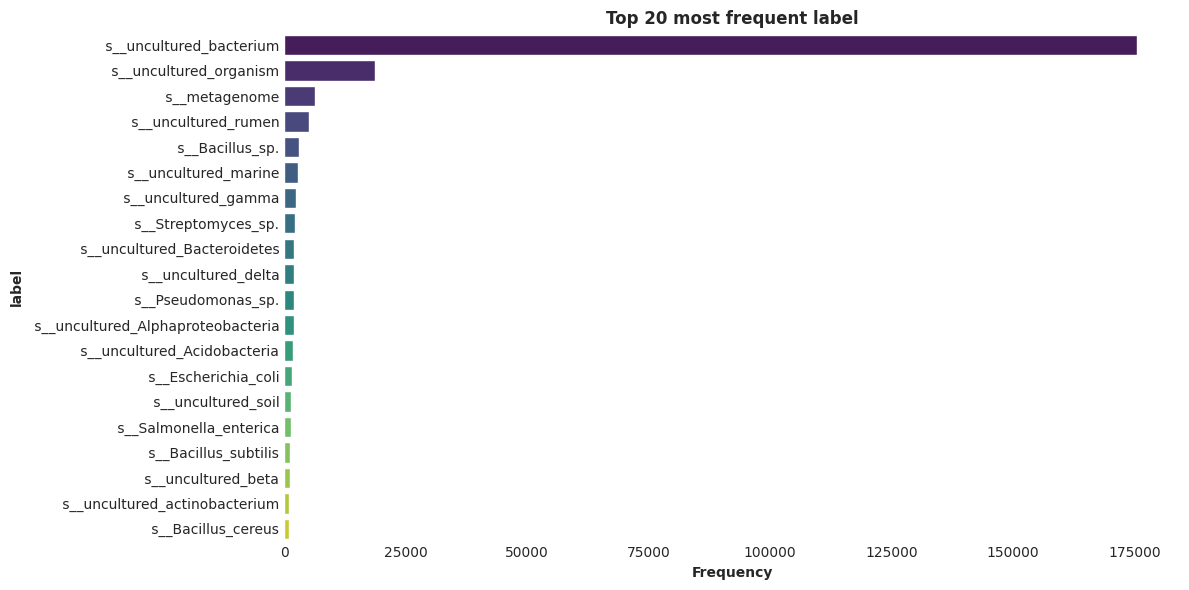

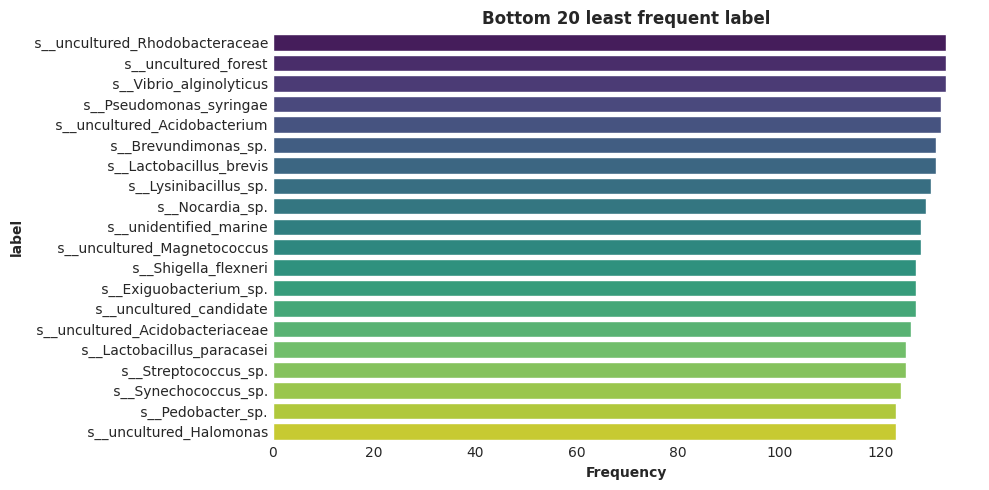

📊 Frequency plots saved to: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset/species


🧹 FILTERING UNWANTED LABELS
   Keywords to filter: ['uncultured', 'uncultivated', 'metagenome', 'metagenomic', 'unidentified', 'unknown', 'unclassified', 'environmental', 'clone']
   Case sensitive: False

📊 BEFORE FILTERING:
   • Total samples: 275,420
   • Total classes: 157

✅ AFTER FILTERING:
   • Remaining samples: 38,272
   • Remaining classes: 101

📉 FILTERED OUT:
   • Samples removed: 237,148 (86.10%)
   • Classes removed: 56 (35.67%)

   📋 Breakdown by keyword:
      • 'uncultured': 229,410 samples
      • 'metagenome': 6,902 samples
      • 'unidentified': 836 samples

🌳 APPLYING HIERARCHICAL GROUPING

🌳 HIERARCHICAL RARE CLASS GROUPING
   Threshold: 2 samples
   Strategy: group
   ✅ No rare classes found (all classes ≥ 2 samples)

📊 APPLYING CENTROID-BASED UNDERSAMPLING
   Strategy: centroid_closest

📊 CENTROID CLOSEST SAMPLING
   Sample fraction: 0.95
   Min

In [ ]:
# ✅ BEST PRACTICE: Preserve ALL rare taxa
csv_paths, paths_file = run_extract_(
    df_tax,
    columns_select=['species'],
    output_path='/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset',
    
    kmer_size=6,

    # ✅ NEW: Clean ambiguous bases
    filter_ambiguous_bases=True,
    ambiguous_handling='replace',      # Most conservative, "remove", "replace", "random"
    max_ambiguous_ratio=0.01,         # Allow max 1% ambiguous

    # ✅ NEW: Filtering configuration (DEFAULT)
    filter_uncultured=True,      # Remove 'uncultured' labels
    filter_metagenome=True,       # Remove 'metagenome' labels
    filter_unidentified=True,     # Remove 'unknown', 'unidentified'
    filter_environmental=True,   # Keep 'environmental' labels

    # 🆕 Keep all classes initially
    min_sample_freq=122,           # ✅ NO initial filtering
    
    # Balancing strategy
    imbalance_strategy='hierarchical_grouping',
    hierarchical_grouping=True,   # Group rare by species

    # Balancing Using Under Sampling
    sampling_strategy='centroid_closest', # None untuk ambil semua data "centroid_closest","centroid_kmeans", "stratified","balanced"
    sample_fraction= 0.95,# 0.01, # jumlah baris yang diambil/disampel
    small_class_threshold= 2, # 20,     # Group if <10 samples, ✅ Group rare classes
    small_class_strategy='group',
    min_samples_per_class=500, # ✅ Ensure minimum per class
    
    # 🆕 Keep only top 100 classes (AFTER balancing)
    top_n_classes=100,  # ← NEW! Integer 100, 50, 200, etc.

    # Visualization
    create_plots=True,
    plot_top_n=False
)

## Cek Ambiguous

In [ ]:
import pandas as pd

# Load your data
df = pd.read_csv("/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset/species/species_sampled.csv")

# Check for ambiguous k-mers
ambiguous_bases = set('NRYKHDBVSWM')
ambiguous_kmers = []

for col in df.columns:
    if col.startswith('kmer_'):
        kmer = col.replace('kmer_', '')
        if any(base in ambiguous_bases for base in kmer):
            ambiguous_kmers.append(kmer)

print(f"🔍 Found {len(ambiguous_kmers)} ambiguous k-mers:")
print(f"   Examples: {ambiguous_kmers[:20]}")

# Calculate percentage
total_kmers = sum(1 for col in df.columns if col.startswith('kmer_'))
ambig_percentage = len(ambiguous_kmers) / total_kmers * 100
print(f"\n📊 Ambiguous k-mers: {ambig_percentage:.2f}% of total")

🔍 Found 0 ambiguous k-mers:
   Examples: []

📊 Ambiguous k-mers: 0.00% of total


## Plot Analysis Dataset

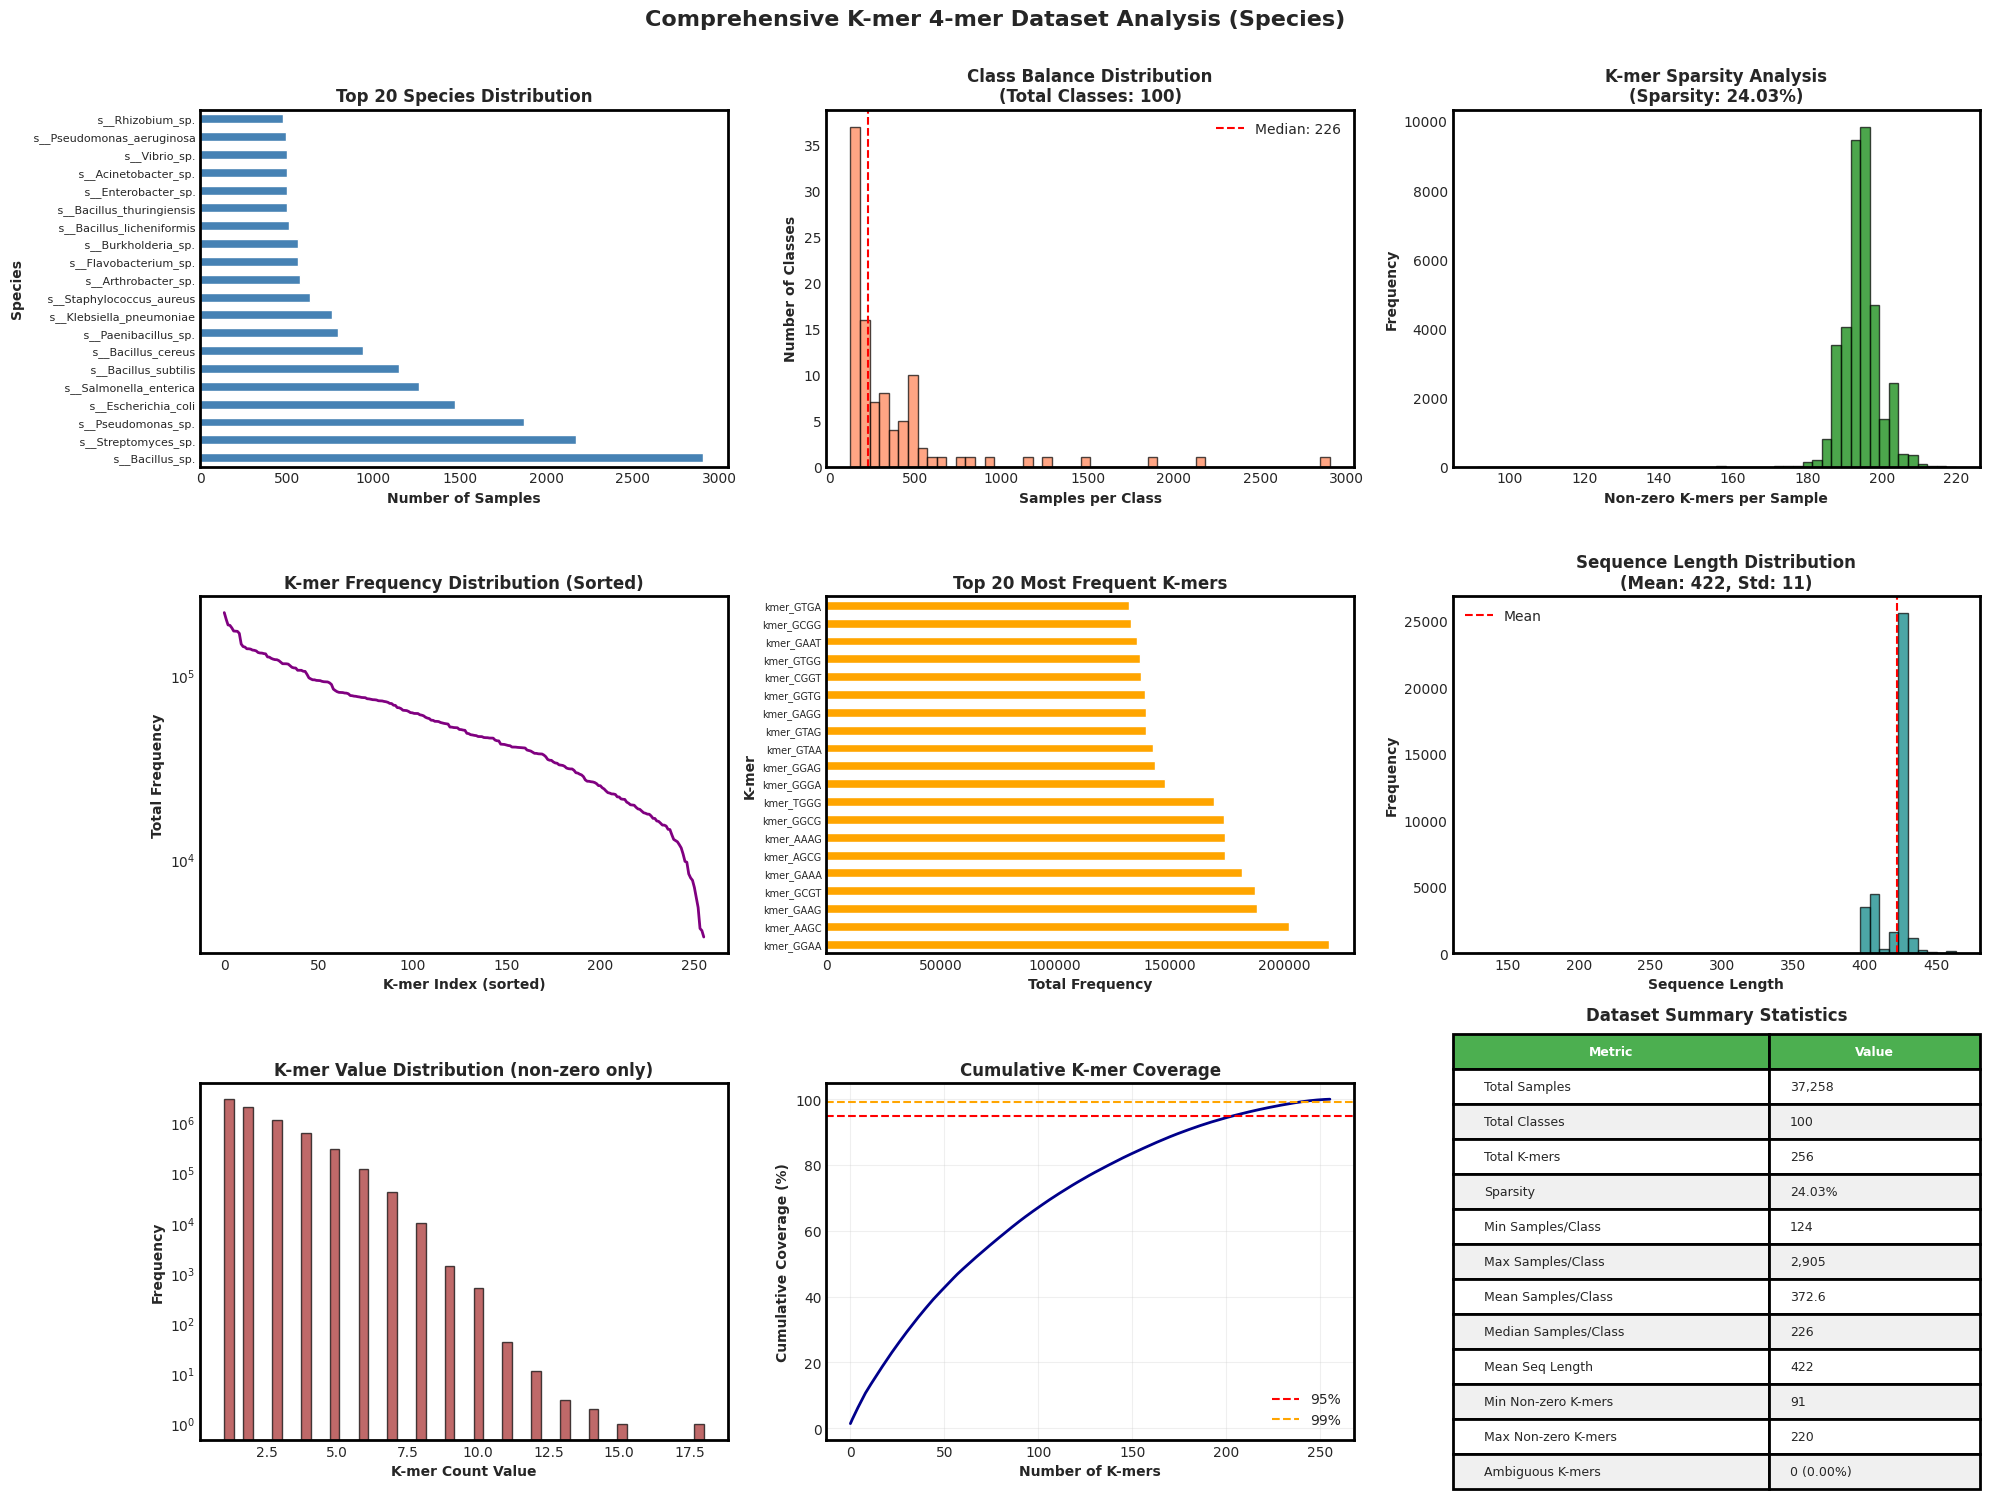


📊 ANALYSIS COMPLETE
✅ Generated 9 comprehensive plots covering:
   • Class distribution and balance
   • K-mer sparsity and frequency patterns
   • Sequence characteristics
   • Statistical summaries


In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

level='species'
kmer_size=8

cek_sample = pd.read_csv(f"/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset/{level}/{level}_sampled.csv")
cek_sample

# Set style
sns.set_style("white")
plt.rcParams['figure.figsize'] = (16, 12)

# Create comprehensive analysis plots
fig = plt.figure(figsize=(20, 15))

# 1. Class Distribution (Top 20)
ax1 = plt.subplot(3, 3, 1)
class_counts = cek_sample['label'].value_counts().head(20)
class_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Number of Samples', fontsize=10, fontweight='bold')
ax1.set_ylabel(f'{level.capitalize()}', fontsize=10, fontweight='bold')
ax1.set_title(f'Top 20 {level.capitalize()} Distribution', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelsize=8)
for spine in ax1.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 2. Overall Class Distribution
ax2 = plt.subplot(3, 3, 2)
total_classes = cek_sample['label'].nunique()
samples_per_class = cek_sample['label'].value_counts()
ax2.hist(samples_per_class, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Samples per Class', fontsize=10, fontweight='bold')
ax2.set_ylabel('Number of Classes', fontsize=10, fontweight='bold')
ax2.set_title(f'Class Balance Distribution\n(Total Classes: {total_classes})', fontsize=12, fontweight='bold')
ax2.axvline(samples_per_class.median(), color='red', linestyle='--', label=f'Median: {samples_per_class.median():.0f}')
ax2.legend()
for spine in ax2.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 3. K-mer Sparsity
ax3 = plt.subplot(3, 3, 3)
kmer_cols = [col for col in cek_sample.columns if col.startswith('kmer_')]
sparsity = (cek_sample[kmer_cols] == 0).sum().sum() / (len(cek_sample) * len(kmer_cols)) * 100
non_zero_counts = (cek_sample[kmer_cols] != 0).sum(axis=1)
ax3.hist(non_zero_counts, bins=50, color='green', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Non-zero K-mers per Sample', fontsize=10, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax3.set_title(f'K-mer Sparsity Analysis\n(Sparsity: {sparsity:.2f}%)', fontsize=12, fontweight='bold')
for spine in ax3.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 4. K-mer Frequency Distribution
ax4 = plt.subplot(3, 3, 4)
kmer_totals = cek_sample[kmer_cols].sum(axis=0).sort_values(ascending=False)
ax4.plot(range(len(kmer_totals)), kmer_totals.values, color='purple', linewidth=2)
ax4.set_xlabel('K-mer Index (sorted)', fontsize=10, fontweight='bold')
ax4.set_ylabel('Total Frequency', fontsize=10, fontweight='bold')
ax4.set_title('K-mer Frequency Distribution (Sorted)', fontsize=12, fontweight='bold')
ax4.set_yscale('log')
for spine in ax4.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 5. Top 20 Most Frequent K-mers
ax5 = plt.subplot(3, 3, 5)
top_kmers = kmer_totals.head(20)
top_kmers.plot(kind='barh', ax=ax5, color='orange')
ax5.set_xlabel('Total Frequency', fontsize=10, fontweight='bold')
ax5.set_ylabel('K-mer', fontsize=10, fontweight='bold')
ax5.set_title('Top 20 Most Frequent K-mers', fontsize=12, fontweight='bold')
ax5.tick_params(axis='y', labelsize=7)
for spine in ax5.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 6. Sequence Length Distribution
ax6 = plt.subplot(3, 3, 6)
seq_lengths = cek_sample['sequence'].str.len()
ax6.hist(seq_lengths, bins=50, color='teal', edgecolor='black', alpha=0.7)
ax6.set_xlabel('Sequence Length', fontsize=10, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax6.set_title(f'Sequence Length Distribution\n(Mean: {seq_lengths.mean():.0f}, Std: {seq_lengths.std():.0f})', 
              fontsize=12, fontweight='bold')
ax6.axvline(seq_lengths.mean(), color='red', linestyle='--', label=f'Mean')
ax6.legend()
for spine in ax6.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 7. K-mer Value Distribution (log scale)
ax7 = plt.subplot(3, 3, 7)
all_kmer_values = cek_sample[kmer_cols].values.flatten()
all_kmer_values = all_kmer_values[all_kmer_values > 0]  # Only non-zero values
ax7.hist(all_kmer_values, bins=50, color='brown', edgecolor='black', alpha=0.7)
ax7.set_xlabel('K-mer Count Value', fontsize=10, fontweight='bold')
ax7.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax7.set_title('K-mer Value Distribution (non-zero only)', fontsize=12, fontweight='bold')
ax7.set_yscale('log')
for spine in ax7.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 8. Cumulative K-mer Coverage
ax8 = plt.subplot(3, 3, 8)
cumsum_kmers = kmer_totals.cumsum() / kmer_totals.sum() * 100
ax8.plot(range(len(cumsum_kmers)), cumsum_kmers.values, color='darkblue', linewidth=2)
ax8.set_xlabel('Number of K-mers', fontsize=10, fontweight='bold')
ax8.set_ylabel('Cumulative Coverage (%)', fontsize=10, fontweight='bold')
ax8.set_title('Cumulative K-mer Coverage', fontsize=12, fontweight='bold')
ax8.axhline(95, color='red', linestyle='--', label='95%')
ax8.axhline(99, color='orange', linestyle='--', label='99%')
ax8.legend()
ax8.grid(True, alpha=0.3)
for spine in ax8.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# 9. Summary Statistics Table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
ax9.set_facecolor('white')
summary_stats = [
    ['Total Samples', f'{len(cek_sample):,}'],
    ['Total Classes', f'{total_classes:,}'],
    ['Total K-mers', f'{len(kmer_cols):,}'],
    ['Sparsity', f'{sparsity:.2f}%'],
    ['Min Samples/Class', f'{samples_per_class.min():,}'],
    ['Max Samples/Class', f'{samples_per_class.max():,}'],
    ['Mean Samples/Class', f'{samples_per_class.mean():.1f}'],
    ['Median Samples/Class', f'{samples_per_class.median():.0f}'],
    ['Mean Seq Length', f'{seq_lengths.mean():.0f}'],
    ['Min Non-zero K-mers', f'{non_zero_counts.min():,}'],
    ['Max Non-zero K-mers', f'{non_zero_counts.max():,}'],
    ['Ambiguous K-mers', f'{len(ambiguous_kmers)} ({ambig_percentage:.2f}%)'],
]

table = ax9.table(cellText=summary_stats, 
                  colLabels=['Metric', 'Value'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style the table
for i in range(len(summary_stats) + 1):
    if i == 0:
        table[(i, 0)].set_facecolor('#4CAF50')
        table[(i, 1)].set_facecolor('#4CAF50')
        table[(i, 0)].set_text_props(weight='bold', color='white')
        table[(i, 1)].set_text_props(weight='bold', color='white')
    else:
        table[(i, 0)].set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')
        table[(i, 1)].set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

# Add border to table
for key, cell in table.get_celld().items():
    cell.set_linewidth(2)
    cell.set_edgecolor('black')

ax9.set_title('Dataset Summary Statistics', fontsize=12, fontweight='bold', pad=40, y=1.02)

plt.suptitle(f'Comprehensive K-mer {kmer_size}-mer Dataset Analysis ({level.capitalize()})', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(f'/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset/{level}/kmer_dataset_analysis_comprehensive_{level}.png', dpi=300)
plt.show()

print("\n" + "="*80)
print("📊 ANALYSIS COMPLETE")
print("="*80)
print(f"✅ Generated 9 comprehensive plots covering:")
print("   • Class distribution and balance")
print("   • K-mer sparsity and frequency patterns")
print("   • Sequence characteristics")
print("   • Statistical summaries")
print("="*80)

## Plot 2 Component

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
from collections import Counter

import matplotlib.pyplot as plt

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Extract features and labels
kmer_cols = [col for col in cek_sample.columns if col.startswith('kmer_')]
X = cek_sample[kmer_cols].values
y = cek_sample['label'].values

# Get unique labels and their counts
unique_labels = np.unique(y)
n_classes = len(unique_labels)

print(f"📊 Preparing PCA visualization...")
print(f"   • Total samples: {X.shape[0]:,}")
print(f"   • Total features: {X.shape[1]:,}")
print(f"   • Total classes: {n_classes}")

# Perform PCA
print(f"\n🔄 Computing PCA (2 components)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"✅ PCA completed!")
print(f"   • Explained variance (PC1): {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"   • Explained variance (PC2): {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"   • Total explained variance: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# Create visualization with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: PCA scatter plot (all classes)
ax1 = axes[0]
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=np.arange(len(y)), 
                     cmap='tab20c', 
                     alpha=0.6, 
                     s=20,
                     edgecolors='none')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', 
              fontsize=12, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', 
              fontsize=12, fontweight='bold')
ax1.set_title(f'PCA Visualization - All Classes (n={n_classes})', 
             fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add border
for spine in ax1.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# Plot 2: PCA with top 10 classes highlighted
ax2 = axes[1]

# Get top 10 most frequent classes
class_counts = Counter(y)
top_10_classes = [cls for cls, _ in class_counts.most_common(10)]

# Create color map
colors = plt.cm.tab10(np.linspace(0, 1, 10))
color_dict = {cls: colors[i] for i, cls in enumerate(top_10_classes)}

# Plot: gray for others, colored for top 10
for i, label in enumerate(y):
    if label in top_10_classes:
        color = color_dict[label]
        alpha = 0.7
        s = 30
        zorder = 2
    else:
        color = 'lightgray'
        alpha = 0.3
        s = 10
        zorder = 1
    
    ax2.scatter(X_pca[i, 0], X_pca[i, 1], 
               c=[color], alpha=alpha, s=s, 
               edgecolors='none', zorder=zorder)

# Add legend for top 10 classes
legend_elements = [plt.scatter([], [], c=[color_dict[cls]], 
                              s=50, label=f'{cls} (n={class_counts[cls]})', 
                              alpha=0.7)
                  for cls in top_10_classes]
ax2.legend(handles=legend_elements, 
          loc='upper right', 
          fontsize=8,
          framealpha=0.9,
          title='Top 10 Classes',
          title_fontsize=10)

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', 
              fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', 
              fontsize=12, fontweight='bold')
ax2.set_title('PCA Visualization - Top 10 Classes Highlighted', 
             fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add border
for spine in ax2.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.savefig('/kaggle/working/SCALR-Tax/rki_2025/dataset/species/PCA_2_Crud_dataset.png', dpi=300)
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("📊 PCA SUMMARY")
print("="*80)
print(f"PC1 range: [{X_pca[:, 0].min():.2f}, {X_pca[:, 0].max():.2f}]")
print(f"PC2 range: [{X_pca[:, 1].min():.2f}, {X_pca[:, 1].max():.2f}]")
print(f"\n🏆 Top 10 Most Frequent Classes:")
for i, (cls, count) in enumerate(class_counts.most_common(10), 1):
    print(f"   {i:2d}. {cls:35s} - {count:4d} samples")
print("="*80)

📊 Preparing PCA visualization...
   • Total samples: 79,013
   • Total features: 256
   • Total classes: 3369

🔄 Computing PCA (2 components)...
✅ PCA completed!
   • Explained variance (PC1): 0.1574 (15.74%)
   • Explained variance (PC2): 0.0951 (9.51%)
   • Total explained variance: 0.2525 (25.25%)


# Vektorisasi

In [ ]:
taxonomy_paths_txt = "/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset/csv_level_paths_list.txt"  # Your txt file with paths
output_base_path = "/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/prep"  # Base path for output

# Run the complete process with monitoring
print("🔧 Initializing vectorization pipeline...")

vectorization_paths, summary, all_paths = main_vectorization_process(
    taxonomy_paths_txt=taxonomy_paths_txt,
    output_base_path=output_base_path,
    k_values=[8], #[4,6,8] # Use 'auto' for automatic selection
    test_size=0.25,      # 25% for testing
    random_state=42,     # For reproducibility
    save_sparse=True,  # ✅ Generate .npz files ✅ ENABLE sparse format
    save_dense=True,    # ✅ Generate .npy files ✅ Keep dense too
    skip_existing=False # ✅ FORCE regenerate
)


🔧 Initializing vectorization pipeline...

🚀 STARTING VECTORIZATION PIPELINE

📂 Found 1 CSV files to process

📊 PROCESSING FILE 1/1
📁 Input: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/dataset/species/species_sampled.csv

   ✅ Loaded: 37,258 rows × 258 columns

   🔍 Detected 256 k-mer columns
   📋 Using manual k-mer sizes: [4]

   ──────────────────────────────────────────────────────────────────────
   🧬 Processing k=4
   ──────────────────────────────────────────────────────────────────────
   📊 K-mer column validation:
      • Valid k=4 columns: 256
      • Invalid/ambiguous: 0

   📦 Dataset preparation:
      • Features shape: (37258, 256)
      • Labels shape: (37258,)
      • Unique classes: 100

   ✂️  Splitting data (test_size=0.25)...
      • Train: 27,943 samples
      • Test:  9,315 samples

   🏷️  Encoding labels...
      • Classes encoded: 100
      • Sample classes: [' s__Acinetobacter_baumannii' ' s__Acinetobacter_sp.'
 ' s__Aeromonas_hydrophil

# Feature Reduction

In [ ]:
results = run_benchmark(
        data_path='/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/prep/vectorization',
        output_dir='/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/reduction',
        levels=['species'],
        kmers=[8],                           
        methods=['ipca'],   # ['pca', 'ipca', 'svd', 'nmf', 'umap', 'tsne']
        max_memory_gb=20.0,
        cev_threshold=0.80,           # 👈 Target 95%
        start_components=10,                           
        step_components=10,           # 👈 Nambah 50 setiap iterasi
        max_components=10000,          # 👈 Maksimal 1000 komponen
        create_plots=True,
    
        # 🎲 Enable sampling
        enable_sampling=False,
        sampling_kmer_threshold=8,  # Sample only k>=8
        sampling_percentage=0.005,     # 50% per class
        min_samples_per_class=2,     # Skip classes with <2 samples, if we add 0 therefore all class will be process
        max_samples_per_class=5000,  # Optional: max limit
    ) 


🚀 Starting Memory-Safe Benchmark with Stratified Sampling
⚙️  Max memory per operation: 20.0GB
🧠 Initial Memory: 3.81GB used, 6.05GB available (51.2%)

🧬 SPECIES - K-mer 4
🧠 Before loading species k4 Memory: 3.81GB used, 6.05GB available (51.2%)
📂 Loading species k4 (train)...
   🔍 Looking for:
      X: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/prep/vectorization/species/k4/X_train_sparse_k4_species.npz
      y: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/prep/vectorization/species/k4/y_train_k4_species.csv
   ✅ Files validated
   📥 Loading sparse matrix...
      ✅ Loaded sparse matrix: (27943, 256)
      📊 Sparsity: 24.03%
   📥 Loading labels...
      ✅ Loaded labels: 27943 samples
      📊 Unique classes: 100
   ✅ Data loaded successfully
   💾 Sparse size: 0.04GB
   ⚠️  Dense would be: 0.06GB
🧠 After loading species k4 Memory: 3.82GB used, 6.05GB available (51.2%)
🧠 Before loading species k4 Memory: 3.82GB used, 6.05GB availabl

   Transforming data for metrics...

   ✅ CEV: 0.5177 (51.77%)

   🔬 Computing comprehensive metrics for n=5...
      1️⃣  Computing MSE...
         ✅ MSE: 0.403920
      2️⃣  Computing distance correlation...
         ✅ Correlation: 0.8124
      3️⃣  Estimating intrinsic dimensionality...
         ✅ Intrinsic dim: 3.92
      4️⃣  Time: 2.05s | Memory: 220.84 MB

──────────────────────────────────────────────────────────────────────
   Testing n_components = 10
──────────────────────────────────────────────────────────────────────


   Transforming data for metrics...

   ✅ CEV: 0.6375 (63.75%)

   🔬 Computing comprehensive metrics for n=10...
      1️⃣  Computing MSE...
         ✅ MSE: 0.309026
      2️⃣  Computing distance correlation...
         ✅ Correlation: 0.8596
      3️⃣  Estimating intrinsic dimensionality...
         ✅ Intrinsic dim: 5.01
      4️⃣  Time: 1.88s | Memory: 220.84 MB

──────────────────────────────────────────────────────────────────────
   Testing n_components = 15
──────────────────────────────────────────────────────────────────────


   Transforming data for metrics...

   ✅ CEV: 0.7098 (70.98%)

   🔬 Computing comprehensive metrics for n=15...
      1️⃣  Computing MSE...
         ✅ MSE: 0.247279
      2️⃣  Computing distance correlation...
         ✅ Correlation: 0.8892
      3️⃣  Estimating intrinsic dimensionality...
         ✅ Intrinsic dim: 5.03
      4️⃣  Time: 1.79s | Memory: 220.84 MB

──────────────────────────────────────────────────────────────────────
   Testing n_components = 20
──────────────────────────────────────────────────────────────────────


   Transforming data for metrics...

   ✅ CEV: 0.7571 (75.71%)

   🔬 Computing comprehensive metrics for n=20...
      1️⃣  Computing MSE...
         ✅ MSE: 0.206461
      2️⃣  Computing distance correlation...
         ✅ Correlation: 0.9174
      3️⃣  Estimating intrinsic dimensionality...
         ✅ Intrinsic dim: 5.12
      4️⃣  Time: 1.85s | Memory: 220.85 MB

──────────────────────────────────────────────────────────────────────
   Testing n_components = 25
──────────────────────────────────────────────────────────────────────


...

   ✅ PCA feature space plot saved: pca_feature_space_all_labels_test.png
   📊 Creating 3D plot with 3000 samples and 100 classes...
   🎨 Using COLORBAR for 100 classes (too many for legend)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

   ✅ 3D PCA feature space plot saved: pca_feature_space_3d_train.png
⚠️  Too many classes (100) for heatmap, skipping...


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll


✅ SUCCESS: ipca completed!
   📊 Train CEV Score: 0.8026
   🧠 Peak Memory: 3.82GB
   ⏱️  Time: 24.31s
🧠 After ipca Memory: 3.86GB used, 6.03GB available (51.5%)

💾 Summary: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/reduction/summary_1764120422.csv

📊 BENCHMARK SUMMARY
  level  kmer method  n_components  train_cev_score  avg_memory_gb  peak_memory_gb  time_seconds  sampling_enabled
species     4   ipca            27         0.802629       3.808505        3.815674     24.307442             False
🧠 Final Memory: 3.86GB used, 6.02GB available (51.5%)


# Model Validasi

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION & SETUP
# ============================================================

print("="*80)
print("🔧 TRAINING PIPELINE - MULTI-KMER CONFIGURATION")
print("="*80)

# ✅ FIX 1: Better configuration structure
CONFIG = {
    'base_path': '/home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025',
    'levels': ['species'],
    'kmers': ['k8'],
    'method': 'ipca',
    'device': 'cpu',
    'use_partial_fit': False,  # Enable partial fit
    'models': [['NaiveBayes','RandomForest','SVC']],  # ✅ IMPROVED: Added 'NaiveBayes', 'RandomForest','SVC','LightGBM'
    'training_params': {
        'use_partial_fit': False,
        'batch_size': 1000,
        'create_plots': True,
        'enable_tuning': True,
        'optimization': 'bayesian',  # 'bayesian' or 'grid'
        'cv_folds': 5,
        'n_iter': 15,
        'auto_skip_conflict': False,
        # 'random_state': 42,
        # 'verbose': 1,
    }
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def validate_paths(level, kmer, method, base_path):
    """✅ FIX 2: Validate all required files exist before training"""
    
    required_files = {
        'X_train': f"{base_path}/reduction/{level}/{kmer}/{method}/features_fold0_train.csv",
        'X_test': f"{base_path}/reduction/{level}/{kmer}/{method}/features_fold0_test.csv",
        'y_train': f"{base_path}/prep/vectorization/{level}/{kmer}/y_train_{kmer}_{level}.csv",
        'y_test': f"{base_path}/prep/vectorization/{level}/{kmer}/y_test_{kmer}_{level}.csv",
        'encoder': f"{base_path}/prep/vectorization/{level}/{kmer}/label_encoder_{kmer}_{level}.pkl",
    }
    
    missing_files = []
    for file_type, file_path in required_files.items():
        if not os.path.exists(file_path):
            missing_files.append(f"❌ {file_type}: {file_path}")
    
    if missing_files:
        print(f"\n🚨 MISSING FILES for {level}_{kmer}_{method}:")
        for msg in missing_files:
            print(f"   {msg}")
        return False, required_files
    
    return True, required_files


def load_data_safe(required_files):
    """✅ FIX 3: Safe data loading with detailed error messages"""
    
    try:
        print("\n   📂 Loading training data...")
        X_train_path = required_files['X_train']
        df_X_train = pd.read_csv(X_train_path)
        print(f"      ✅ X_train: {df_X_train.shape}")
        
        print("   📂 Loading test data...")
        X_test_path = required_files['X_test']
        df_X_test = pd.read_csv(X_test_path)
        print(f"      ✅ X_test: {df_X_test.shape}")
        
        print("   📂 Loading y_train labels...")
        y_train_path = required_files['y_train']
        df_y_train = pd.read_csv(y_train_path)
        y_train = df_y_train.iloc[:, 0].values  # Get first column
        print(f"      ✅ y_train: {len(y_train)} samples, {len(np.unique(y_train))} classes")
        
        print("   📂 Loading y_test labels...")
        y_test_path = required_files['y_test']
        df_y_test = pd.read_csv(y_test_path)
        y_test = df_y_test.iloc[:, 0].values
        print(f"      ✅ y_test: {len(y_test)} samples, {len(np.unique(y_test))} classes")
        
        print("   📂 Loading label encoder...")
        encoder_path = required_files['encoder']
        import joblib
        label_encoder = joblib.load(encoder_path)
        print(f"      ✅ Encoder: {len(label_encoder.classes_)} classes")
        
        # ✅ FIX 4: Extract features (remove label column if exists)
        if 'label' in df_X_train.columns:
            X_train = df_X_train.drop(columns=['label']).values
        else:
            X_train = df_X_train.values
            
        if 'label' in df_X_test.columns:
            X_test = df_X_test.drop(columns=['label']).values
        else:
            X_test = df_X_test.values
        
        # ✅ FIX 5: Data consistency check
        print("\n   🔍 Data consistency check:")
        if X_train.shape[0] != len(y_train):
            raise ValueError(f"Mismatch: X_train ({X_train.shape[0]}) != y_train ({len(y_train)})")
        if X_test.shape[0] != len(y_test):
            raise ValueError(f"Mismatch: X_test ({X_test.shape[0]}) != y_test ({len(y_test)})")
        print(f"      ✅ X_train matches y_train")
        print(f"      ✅ X_test matches y_test")
        
        # ✅ FIX 6: Check for class imbalance
        unique_train, counts_train = np.unique(y_train, return_counts=True)
        print(f"\n   📊 Train set class distribution:")
        for cls, cnt in zip(unique_train[:5], counts_train[:5]):
            print(f"      Class {cls}: {cnt} samples")
        if len(unique_train) > 5:
            print(f"      ... and {len(unique_train)-5} more classes")
        
        return {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'label_encoder': label_encoder,
            'dataset_info': {
                'n_features': X_train.shape[1],
                'n_classes': len(np.unique(y_train)),
                'n_train': X_train.shape[0],
                'n_test': X_test.shape[0],
            }
        }
        
    except Exception as e:
        print(f"      ❌ Error loading data: {e}")
        import traceback
        traceback.print_exc()
        return None


def create_output_dir(base_path, level, kmer, method, device):
    """✅ FIX 7: Ensure output directory exists"""
    
    output_path = Path(f"{base_path}/model/{level}_{kmer}_{method}_{device}")
    output_path.mkdir(parents=True, exist_ok=True)
    return str(output_path)


# ============================================================
# MAIN TRAINING LOOP
# ============================================================

print("\n" + "="*80)
print("📊 STARTING TRAINING PIPELINE")
print("="*80)

# ✅ FIX 8: Improved loop structure with better error handling
training_results = []
failed_configs = []

for level in CONFIG['levels']:
    for kmer in CONFIG['kmers']:
        for method in [CONFIG['method']]:
            for device in [CONFIG['device']]:
                for models_list in CONFIG['models']:
                    
                    config_name = f"{level}_{kmer}_{method}_{device}"
                    print(f"\n{'='*80}")
                    print(f"🔄 TRAINING CONFIG: {config_name}")
                    print(f"   Models: {', '.join(models_list)}")
                    print(f"{'='*80}")
                    
                    # ✅ STEP 1: Validate paths
                    print(f"\n1️⃣  VALIDATING PATHS...")
                    is_valid, required_files = validate_paths(level, kmer, method, CONFIG['base_path'])
                    
                    if not is_valid:
                        print(f"   ❌ Validation failed - skipping this configuration")
                        failed_configs.append({
                            'config': config_name,
                            'reason': 'Missing files'
                        })
                        continue
                    
                    print(f"   ✅ All paths valid")
                    
                    # ✅ STEP 2: Load data
                    print(f"\n2️⃣  LOADING DATA...")
                    data = load_data_safe(required_files)
                    
                    if data is None:
                        print(f"   ❌ Data loading failed - skipping this configuration")
                        failed_configs.append({
                            'config': config_name,
                            'reason': 'Data loading error'
                        })
                        continue
                    
                    # ✅ STEP 3: Create output directory
                    print(f"\n3️⃣  CREATING OUTPUT DIRECTORY...")
                    output_dir = create_output_dir(
                        CONFIG['base_path'], level, kmer, method, device
                    )
                    print(f"   📁 Output: {output_dir}")
                    
                    # ✅ STEP 4: Train models
                    print(f"\n4️⃣  TRAINING MODELS ({len(models_list)} models)...")
                    
                    try:
                        # Merge training parameters
                        training_config = {
                            **CONFIG['training_params'],
                            'dataset_name': config_name,
                            'output_dir': output_dir,
                        }
                        
                        print(f"   Training config:")
                        for key, value in training_config.items():
                            if key not in ['dataset_name', 'output_dir']:
                                print(f"      • {key}: {value}")
                        
                        # Run training pipeline
                        results_df, best_model_name, best_model = run_training_pipeline(
                            X_train=data['X_train'],
                            X_test=data['X_test'],
                            y_train=data['y_train'],
                            y_test=data['y_test'],
                            label_encoder=data['label_encoder'],
                            selected_models=models_list,
                            **training_config
                        )
                        
                        # ✅ STEP 5: Process results
                        if results_df is not None:
                            print(f"\n   ✅ TRAINING COMPLETED SUCCESSFULLY")
                            
                            # Display results table
                            print(f"\n   📊 RESULTS SUMMARY:")
                            print(f"   {'-'*75}")
                            print(results_df.to_string(index=False))
                            print(f"   {'-'*75}")
                            
                            # Highlight best model
                            print(f"\n   🏆 BEST MODEL: {best_model_name}")
                            best_row = results_df[results_df['Model'] == best_model_name].iloc[0]
                            print(f"      • Accuracy: {best_row['Accuracy']:.4f}")
                            print(f"      • F1_Macro: {best_row['F1_Macro']:.4f}")  # ✅ CHANGED
                            print(f"      • Train_Time_Seconds: {best_row['Train_Time_Seconds']:.2f}s")  # ✅ CHANGED
                            
                            # Save results to CSV
                            results_csv_path = os.path.join(
                                output_dir,
                                f"training_results_{config_name}.csv"
                            )
                            results_df.to_csv(results_csv_path, index=False)
                            print(f"\n   💾 Results saved: {results_csv_path}")
                            
                            # Store for summary
                            training_results.append({
                                'config': config_name,
                                'best_model': best_model_name,
                                'accuracy': best_row['Accuracy'],
                                'f1_macro': best_row['F1_Macro'],  # ✅ CHANGED from f1_score
                                'status': '✅ SUCCESS'
                            })
                            
                        else:
                            print(f"   ❌ Training failed - no results generated")
                            failed_configs.append({
                                'config': config_name,
                                'reason': 'No results from training'
                            })
                    
                    except Exception as e:
                        print(f"   ❌ Error during training: {e}")
                        import traceback
                        traceback.print_exc()
                        
                        failed_configs.append({
                            'config': config_name,
                            'reason': str(e)
                        })

# ============================================================
# FINAL SUMMARY
# ============================================================

print(f"\n{'='*80}")
print(f"📋 TRAINING PIPELINE SUMMARY")
print(f"{'='*80}")

if training_results:
    print(f"\n✅ SUCCESSFUL TRAININGS ({len(training_results)}):")
    results_summary_df = pd.DataFrame(training_results)
    print(results_summary_df.to_string(index=False))
    
    # Find best overall
    best_overall_idx = results_summary_df['accuracy'].idxmax()
    best_overall = results_summary_df.iloc[best_overall_idx]
    print(f"\n🏆 BEST OVERALL:")
    print(f"   Config: {best_overall['config']}")
    print(f"   Model: {best_overall['best_model']}")
    print(f"   Accuracy: {best_overall['accuracy']:.4f}")
    print(f"   F1_Macro: {best_overall['f1_macro']:.4f}")  # ✅ ADDED

if failed_configs:
    print(f"\n❌ FAILED TRAININGS ({len(failed_configs)}):")
    for failed in failed_configs:
        print(f"   • {failed['config']}: {failed['reason']}")

print(f"\n{'='*80}")
print(f"✅ TRAINING PIPELINE COMPLETED")
print(f"{'='*80}\n")

🔧 TRAINING PIPELINE - MULTI-KMER CONFIGURATION

📊 STARTING TRAINING PIPELINE

🔄 TRAINING CONFIG: species_k4_ipca_cpu
   Models: NaiveBayes, RandomForest, SVC

1️⃣  VALIDATING PATHS...
   ✅ All paths valid

2️⃣  LOADING DATA...

   📂 Loading training data...
      ✅ X_train: (27943, 28)
   📂 Loading test data...
      ✅ X_test: (9315, 28)
   📂 Loading y_train labels...
      ✅ y_train: 27943 samples, 100 classes
   📂 Loading y_test labels...
      ✅ y_test: 9315 samples, 100 classes
   📂 Loading label encoder...
      ✅ Encoder: 100 classes

   🔍 Data consistency check:
      ✅ X_train matches y_train
      ✅ X_test matches y_test

   📊 Train set class distribution:
      Class  s__Acinetobacter_baumannii: 128 samples
      Class  s__Acinetobacter_sp.: 375 samples
      Class  s__Aeromonas_hydrophila: 113 samples
      Class  s__Aeromonas_sp.: 112 samples
      Class  s__Agrobacterium_radiobacter: 101 samples
      ... and 95 more classes

3️⃣  CREATING OUTPUT DIRECTORY...
   📁 Output: 

Training models:   0%|          | 0/3 [00:00<?, ?it/s]


⏳ Training NaiveBayes...
   🔧 Tuning enabled for NaiveBayes

🔧 Hyperparameter Tuning: NaiveBayes (BAYESIAN)
   CV Folds: 5
   Parameters to tune: ['classifier__var_smoothing']
   🧠 Using BayesSearchCV (n_iter=15)
   ⏳ Starting search...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 

Training models:  33%|███▎      | 1/3 [00:27<00:55, 27.75s/it]


⏳ Training RandomForest...
   🔧 Tuning enabled for RandomForest

🔧 Hyperparameter Tuning: RandomForest (BAYESIAN)
   CV Folds: 5
   Parameters to tune: ['classifier__n_estimators', 'classifier__max_depth', 'classifier__min_samples_split', 'classifier__min_samples_leaf']
   🧠 Using BayesSearchCV (n_iter=15)
   ⏳ Starting search...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds fo

...


✅ Summary saved: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/model/species_k4_ipca_cpu/species_k4_ipca_cpu/summary.csv
✅ Predictions saved: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/model/species_k4_ipca_cpu/species_k4_ipca_cpu/predictions.csv
✅ Prediction probabilities saved: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/model/species_k4_ipca_cpu/species_k4_ipca_cpu/prediction_probabilities.csv

📊 **TRAINING COMPLETED**
       Model  Accuracy  F1_Macro  Recall_Macro  Precision_Macro  ROC_AUC  Train_Time_Seconds  Predict_Time_Seconds  Peak_Memory_Train_MB  Avg_Memory_Train_MB  Peak_Memory_Predict_MB  Avg_Memory_Predict_MB  Tuned Optimization_Method
RandomForest  0.805368  0.784472      0.788667         0.815428 0.989444             624.250                 2.607               1931.19              3268.44                 3268.69                3342.25   True            bayesian
         SVC  0.802684  0.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

   ℹ️  SVC - Real confidence range: [0.079, 0.994], mean: 0.759


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

💾 Analysis saved: /home/tirta/Dokumen/k4_ambi-prep_centroid_IPCA & SVD/SCALR-Tax/rki_2025/model/species_k4_ipca_cpu/species_k4_ipca_cpu/species_k4_ipca_cpu_comprehensive_analysis.png

   ✅ TRAINING COMPLETED SUCCESSFULLY

   📊 RESULTS SUMMARY:
   ---------------------------------------------------------------------------
       Model  Accuracy  F1_Macro  Recall_Macro  Precision_Macro  ROC_AUC  Train_Time_Seconds  Predict_Time_Seconds  Peak_Memory_Train_MB  Avg_Memory_Train_MB  Peak_Memory_Predict_MB  Avg_Memory_Predict_MB  Tuned Optimization_Method
  NaiveBayes  0.729791  0.731802      0.768192         0.731532 0.988596              26.022                 1.254               1916.79              1922.93                 1922.93                1931.19   True            bayesian
RandomForest  0.805368  0.784472      0.788667         0.815428 0.989444             624.250                 2.607               1931.19              3268.44                 3268.69                3342.25   True  

# Finish